# ¿Entra una red neuronal en el ESP32-CAM?

Este notebook **no entrena nada**. Calcula el presupuesto —cómputo, memoria, energía— de
las variantes candidatas *antes* de gastar en datos y entrenamiento. Es la pregunta previa:
**¿tiene sentido intentarlo?**

## Por qué la respuesta cambió

La literatura dice que el ESP32 original es demasiado lento para TinyML. Eso es cierto
**para video**. El nodo Flamara no hace video: saca **una foto cada varios minutos**.

Espressif publica la latencia medida del ejemplo `person_detection` (MobileNetV1 α=0.25,
96×96 en escala de grises, int8) sobre `esp-tflite-micro` con los kernels **ESP-NN**:

| chip | sin ESP-NN | **con ESP-NN** |
|---|---|---|
| **ESP32 @240 MHz** ← el del ESP32-CAM | 4084 ms | **380 ms** |
| ESP32-S3 @240 MHz | 2300 ms | 54 ms |
| ESP32-C3 @160 MHz | 3355 ms | 426 ms |
| ESP32-P4 @360 MHz | 1395 ms | 73 ms |

380 ms son **2.6 fps** — inútil para video. Para una captura cada 15 minutos, **irrelevante**.

El presupuesto real de este nodo no es latencia: es **energía por captura** y **memoria**.

## Qué framework

`esp-tflite-micro` + ESP-NN, **no ESP-DL**. ESP-DL v2 apunta a ESP32-S3 y P4; el ESP32
original quedó fuera de la rama actual. TFLite Micro sí soporta ESP32 y Espressif lo mantiene.

## Cómo leer los números de acá

Todo sale de un modelo **analítico** de MobileNetV1 (`nn_esp32.py`): cuenta MACs, parámetros
y activaciones capa por capa, y calibra la latencia contra ese **único punto medido**. Es una
regla de tres: sirve para **comparar variantes entre sí**, no como número absoluto. Antes de
comprometer el diseño hay que medir en la placa.

**Ejecutar:**
```bash
cd Desarrollo/Pruebas
uv run jupyter lab notebooks/3_red_neuronal.ipynb
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as W
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox

# Raíz del banco de pruebas = la carpeta que contiene `modulos/`. Así el notebook anda
# tanto abierto desde notebooks/ como desde Pruebas/.
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "modulos").is_dir()), None)
if RAIZ is None:
    raise RuntimeError(f"no encuentro 'modulos/' desde {Path.cwd()}; "
                       "abrí el notebook dentro de Desarrollo/Pruebas/")
sys.path.insert(0, str(RAIZ / "modulos"))
DATOS, SALIDAS = RAIZ / "datos", RAIZ / "salidas"


def ruta_salida(nombre):
    """Ruta dentro de salidas/, creando la carpeta si hace falta.

    Se crea al escribir y no al importar: así la celda de exportar funciona aunque
    se la ejecute sola después de reiniciar el kernel.
    """
    SALIDAS.mkdir(parents=True, exist_ok=True)
    return SALIDAS / nombre
import nn_esp32 as nn
import horizonte_sim as hs      # para comparar contra el pipeline clásico

plt.rcParams.update({"figure.dpi": 110, "font.size": 8})
COL = {"camara": "#4a86c8", "clasico": "#2ba84a", "red": "#ff6b2b", "sleep": "#7a8399"}


def tabla(filas, cols):
    print("".join(f"{t:>{a}}" if i else f"{t:<{a}}" for i, (t, a, _, _) in enumerate(cols)))
    print("-" * sum(a for _, a, _, _ in cols))
    for f in filas:
        out = []
        for i, (_, a, fmt, k) in enumerate(cols):
            v = k(f) if callable(k) else f[k]
            s = format(v, fmt) if fmt else str(v)
            out.append(f"{s:>{a}}" if i else f"{s:<{a}}")
        print("".join(out))

## 1 · El anclaje: qué sabemos con certeza

Un solo punto medido sostiene toda la extrapolación. Conviene mirarlo de frente.

El modelo analítico cuenta **206 kB de pesos** para `person_detection`; el archivo real de
tflite-micro pesa **~250 kB**. La diferencia (cuantización, metadatos del FlatBuffer, buffers
persistentes) es del orden esperado — el conteo sirve.

De la latencia medida sale el **ns/MAC** de cada chip. Ese número es la única constante
empírica del notebook.

person_detection = MobileNetV1 α=0.25 · 96×96×1 · int8
  7.16 MMAC por inferencia
  211 k parámetros → 206 kB de pesos (el .tflite real: ~250 kB)
  pico de activaciones 54 kB

chip            MHz   ms medidos    ns/MAC    MMAC/s   MAC/ciclo
----------------------------------------------------------------
esp32           240          380      53.1        19        0.08
esp32s3         240           54       7.5       133        0.55
esp32c3         160          426      59.5        17        0.11
esp32p4         360           73      10.2        98        0.27

El ESP32 hace ~0.08 MAC por ciclo: sin SIMD, cada MAC int8 cuesta ~13 ciclos entre
carga, multiplicación, acumulación y escritura. El S3 llega a ~0.55 gracias a PIE.


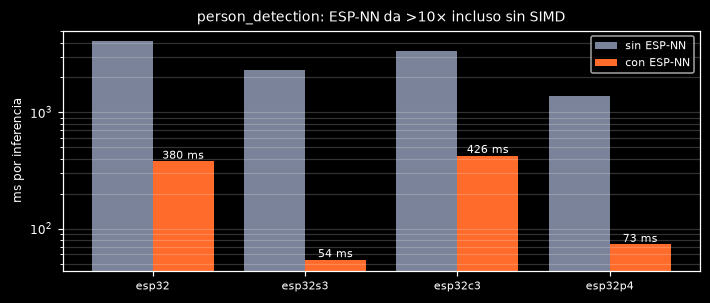

In [2]:
p_ancla = nn.perfil(alpha=0.25, res=96, canales_in=1, clases=2)

print(f"person_detection = MobileNetV1 α=0.25 · 96×96×1 · int8")
print(f"  {p_ancla['macs']/1e6:.2f} MMAC por inferencia")
print(f"  {p_ancla['params']/1e3:.0f} k parámetros → {p_ancla['flash_kb']:.0f} kB de pesos "
      f"(el .tflite real: ~250 kB)")
print(f"  pico de activaciones {p_ancla['pico_act_kb']:.0f} kB\n")

filas = [dict(chip=c, mhz=nn.MHZ[c], ms=nn.LATENCIA_MEDIDA_MS[c],
              ns=nn.ns_por_mac(c), mmacs=1e3/nn.ns_por_mac(c),
              macs_ciclo=(1e9/nn.ns_por_mac(c))/(nn.MHZ[c]*1e6))
         for c in nn.LATENCIA_MEDIDA_MS]
tabla(filas, [("chip", 12, "", "chip"), ("MHz", 7, "d", "mhz"),
              ("ms medidos", 13, "d", "ms"), ("ns/MAC", 10, ".1f", "ns"),
              ("MMAC/s", 10, ".0f", "mmacs"), ("MAC/ciclo", 12, ".2f", "macs_ciclo")])

print("\nEl ESP32 hace ~0.08 MAC por ciclo: sin SIMD, cada MAC int8 cuesta ~13 ciclos entre")
print("carga, multiplicación, acumulación y escritura. El S3 llega a ~0.55 gracias a PIE.")

fig, ax = plt.subplots(figsize=(6.5, 2.8))
chips = list(nn.LATENCIA_MEDIDA_MS)
x = np.arange(len(chips))
sin_nn = {"esp32": 4084, "esp32s3": 2300, "esp32c3": 3355, "esp32p4": 1395}
ax.bar(x - 0.2, [sin_nn[c] for c in chips], 0.4, label="sin ESP-NN", color="#7a8399")
ax.bar(x + 0.2, [nn.LATENCIA_MEDIDA_MS[c] for c in chips], 0.4, label="con ESP-NN", color="#ff6b2b")
for i, c in enumerate(chips):
    ax.annotate(f"{nn.LATENCIA_MEDIDA_MS[c]} ms", (i + 0.2, nn.LATENCIA_MEDIDA_MS[c]),
                ha="center", va="bottom", fontsize=7)
ax.set_yscale("log"); ax.set_xticks(x, chips, fontsize=7)
ax.set_ylabel("ms por inferencia"); ax.legend(fontsize=7)
ax.set_title("person_detection: ESP-NN da >10× incluso sin SIMD", fontsize=9)
ax.grid(alpha=0.2, axis="y", which="both")
plt.tight_layout(); plt.show()

## 2 · Anatomía del modelo: dónde se va el cómputo y dónde el pico de memoria

MobileNetV1 tiene una forma muy marcada, y entenderla es lo que permite recortarlo bien:

- **El cómputo está repartido** de forma bastante pareja entre las capas intermedias.
- **Los parámetros están casi todos al final**: las capas de 512 y 1024 canales concentran
  el peso del archivo. La cola de la red es cara en flash y barata en activaciones.
- **El pico de activaciones está al principio**: las primeras capas tienen mucha resolución
  espacial. La cabeza de la red es cara en flash; la entrada es cara en RAM.

Esa asimetría es la razón por la que **truncar la red** (la idea de FOMO) sale tan barato:
tirás la cola, que es donde están los parámetros, y te quedás con la parte que ya extrajo
las características espaciales.

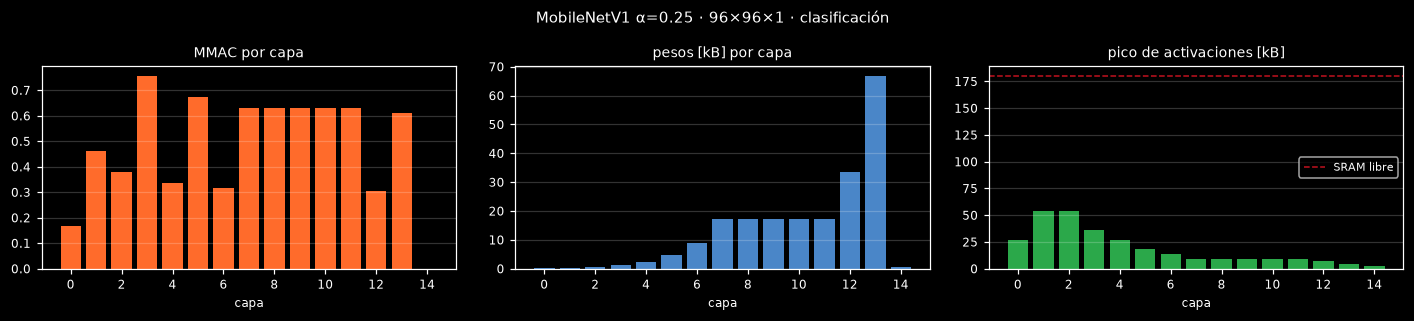

15 capas · 7.16 MMAC · 206 kB de pesos · pico 54 kB
la mitad de los PESOS está después de la capa 11 (de 14)
el pico de ACTIVACIONES está en la capa 1


In [3]:
def anatomia(p, titulo):
    caps = p["capas"]
    i = np.arange(len(caps))
    macs = np.array([c["macs"] for c in caps]) / 1e6
    par = np.array([c["params"] for c in caps]) / 1024
    act = np.array([c["pico"] for c in caps]) / 1024

    fig, ax = plt.subplots(1, 3, figsize=(13, 2.9))
    for a, v, t, col in ((ax[0], macs, "MMAC por capa", COL["red"]),
                         (ax[1], par, "pesos [kB] por capa", "#4a86c8"),
                         (ax[2], act, "pico de activaciones [kB]", "#2ba84a")):
        a.bar(i, v, color=col)
        a.set_xlabel("capa"); a.set_title(t, fontsize=9); a.grid(alpha=0.2, axis="y")
    ax[2].axhline(nn.SRAM_LIBRE_KB, color="#c1121f", ls="--", lw=1, label="SRAM libre")
    ax[2].legend(fontsize=7)
    fig.suptitle(titulo, fontsize=10)
    plt.tight_layout(); plt.show()

    acum_par = np.cumsum(par) / par.sum()
    k = int(np.argmax(acum_par > 0.5))
    print(f"{len(caps)} capas · {macs.sum():.2f} MMAC · {par.sum():.0f} kB de pesos · "
          f"pico {act.max():.0f} kB")
    print(f"la mitad de los PESOS está después de la capa {k} (de {len(caps)-1})")
    print(f"el pico de ACTIVACIONES está en la capa {int(np.argmax(act))}")

anatomia(p_ancla, "MobileNetV1 α=0.25 · 96×96×1 · clasificación")

In [4]:
caps = p_ancla["capas"]
print(f"{'capa':<6}{'tipo':<12}{'salida':>16}{'MMAC':>9}{'pesos kB':>11}{'act in+out kB':>15}")
print("-" * 69)
for c in caps:
    h, w, ch = c["salida"]
    print(f"{c['i']:<6}{c['tipo']:<12}{f'{h}x{w}x{ch}':>16}{c['macs']/1e6:>9.2f}"
          f"{c['params']/1024:>11.1f}{c['pico']/1024:>15.1f}")

capa  tipo                  salida     MMAC   pesos kB  act in+out kB
---------------------------------------------------------------------
0     conv                 48x48x8     0.17        0.1           27.0
1     dw                  48x48x16     0.46        0.2           54.0
2     dw                  24x24x32     0.38        0.7           54.0
3     dw                  24x24x32     0.76        1.3           36.0
4     dw                  12x12x64     0.34        2.4           27.0
5     dw                  12x12x64     0.67        4.7           18.0
6     dw                   6x6x128     0.32        8.8           13.5
7     dw                   6x6x128     0.63       17.4            9.0
8     dw                   6x6x128     0.63       17.4            9.0
9     dw                   6x6x128     0.63       17.4            9.0
10    dw                   6x6x128     0.63       17.4            9.0
11    dw                   6x6x128     0.63       17.4            9.0
12    dw            

## 3 · El espacio de diseño

Cuatro perillas, y no cuestan lo mismo:

| perilla | efecto en MACs | efecto en pesos | efecto en la arena |
|---|---|---|---|
| **resolución** de entrada | ∝ res² | **ninguno** | ∝ res² |
| **α** (ancho de la red) | ≈ ∝ α² | ∝ α² | ∝ α |
| **gris vs RGB** | casi nada (solo 1ª capa) | ninguno | poco |
| **corte** (cabeza FOMO) | recorta la cola | **recorta muchísimo** | ninguno |

Dos consecuencias prácticas:

- **Subir resolución no cuesta flash pero sí RAM y tiempo.** Bajar α cuesta flash y tiempo
  pero poca RAM. Son perillas independientes: se ajustan contra restricciones distintas.
- **RGB es casi gratis en cómputo.** El motivo para ir a gris es de datos y de robustez, no
  de MACs: menos canales, menos parámetros que aprender y menos sensibilidad al balance de
  blancos del OV2640, que de noche hace cualquier cosa.

Movés las perillas y mirás si entra:

In [5]:
@interact(alpha=Dropdown(options=[0.1, 0.25, 0.35, 0.5, 0.75, 1.0], value=0.25, description="α"),
          res=Dropdown(options=[48, 64, 96, 128, 160, 192], value=96, description="resolución"),
          canales_in=Dropdown(options=[("gris", 1), ("RGB", 3)], value=1, description="entrada"),
          clases=IntSlider(2, 1, 8, 1, description="clases"),
          usar_fomo=Checkbox(value=False, description="cabeza FOMO"),
          corte=IntSlider(6, 1, 14, 1, description="cortar en capa"),
          chip=Dropdown(options=list(nn.LATENCIA_MEDIDA_MS), value="esp32", description="chip"))
def explorar(alpha, res, canales_in, clases, usar_fomo, corte, chip):
    p = nn.perfil(alpha, res, canales_in, clases, corte if usar_fomo else None)
    donde, arena = nn.donde_entra(p)
    ms = nn.latencia_ms(p, chip, en_psram=(donde == "PSRAM"))
    e = nn.energia_mj(ms)

    print(f"{p['macs']/1e6:8.2f} MMAC")
    print(f"{p['flash_kb']:8.0f} kB de pesos   ({100*p['flash_kb']/nn.FLASH_KB:.1f}% del flash)")
    print(f"{arena:8.0f} kB de arena    → {donde}")
    print(f"{ms:8.0f} ms en {chip}   ({e:.0f} mJ)")
    if p["grilla"]:
        gh, gw = p["grilla"]
        print(f"\nsalida: grilla {gh}×{gw} = {gh*gw} celdas · {gh*gw*clases} B de mapa de calor")
        print(f"        cada celda cubre {res//gh}×{res//gw} px de la entrada")
        print(f"        bitmask de 1 bit/celda: {int(np.ceil(gh*gw/8))} B  ← cabe en LoRa")
    else:
        print(f"\nsalida: {clases} probabilidades (sin localización)")

    veredicto = ("VIABLE" if donde == "SRAM" and ms < 1000 else
                 "VIABLE con PSRAM" if donde == "PSRAM" and ms < 3000 else
                 "AL LÍMITE" if donde != "NO ENTRA (flash)" and not donde.startswith("NO") else
                 "NO ENTRA")
    print(f"\n>>> {veredicto} en {chip}")

    anatomia(p, f"α={alpha} · {res}×{res}×{canales_in}" + (f" · corte {corte}" if usar_fomo else ""))

interactive(children=(Dropdown(description='α', index=1, options=(0.1, 0.25, 0.35, 0.5, 0.75, 1.0), value=0.25…

## 4 · Clasificar vs FOMO: el resultado más importante del notebook

**Clasificar** responde *¿hay fuego?* — un escalar.
**FOMO** responde *¿dónde?* — una grilla, cortando la red antes de la cola y pegándole una
convolución 1×1 que clasifica cada celda.

La intuición diría que localizar es más caro que clasificar. Con esta arquitectura es al
revés: **FOMO es más barato**, porque la cola que se tira es justamente la parte pesada.

Y hay un encaje que no es casualidad: **el mapa de calor de FOMO *es* el payload**. Una
grilla de 12×12 con 1 bit por celda son 18 bytes — entra en un paquete LoRa con lugar de
sobra, y es exactamente la estructura del flujo "2D pesado" del diagrama de arquitectura.

El pipeline clásico de fuego que ya está en `pipeline_sim.py` (grilla 16×16 + bitmask por
celda) **es un FOMO hecho a mano**. Misma estructura de salida, sin red.

MobileNetV1 α=0.25 · 96×96×1 · 2 clases · ESP32

corte     grilla  px/celda    MMAC  pesos kB  arena kB     ms  bitmask B  memoria
---------------------------------------------------------------------------------
2          48×48         2    0.70         0        70     37        288     SRAM
3          24×24         4    1.04         1        70     55         72     SRAM
4          24×24         4    1.80         2        70     95         72     SRAM
5          12×12         8    2.12         5        70    112         18     SRAM
6          12×12         8    2.79        10        70    148         18     SRAM
7            6×6        16    3.09        18        70    164          5     SRAM
8            6×6        16    3.73        36        70    198          5     SRAM
9            6×6        16    4.36        53        70    231          5     SRAM
10           6×6        16    4.99        71        70    265          5     SRAM
11           6×6        16    5.62        88     

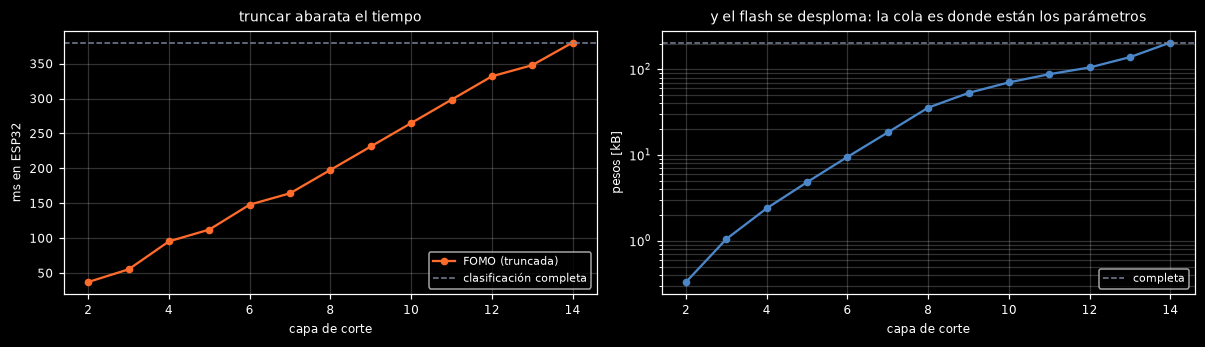


Cortando en la capa 5: grilla 12×12, 112 ms, 5 kB de pesos, 18 B de bitmask.
Contra la clasificación completa: 70% menos tiempo y 98% menos flash, y encima devuelve DÓNDE.


In [6]:
cortes = list(range(2, 15))
filas = []
for k in cortes:
    p = nn.perfil(0.25, 96, 1, 2, corte=k)
    donde, arena = nn.donde_entra(p)
    gh, gw = p["grilla"]
    filas.append(dict(corte=k, grilla=f"{gh}×{gw}", celdas=gh*gw, px=96//gh,
                      mmac=p["macs"]/1e6, kb=p["flash_kb"], arena=arena,
                      ms=nn.latencia_ms(p, "esp32", donde == "PSRAM"),
                      bitmask=int(np.ceil(gh*gw/8)), donde=donde))
p_cls = nn.perfil(0.25, 96, 1, 2)
d_cls, a_cls = nn.donde_entra(p_cls)

print("MobileNetV1 α=0.25 · 96×96×1 · 2 clases · ESP32\n")
tabla(filas, [("corte", 7, "d", "corte"), ("grilla", 9, "", "grilla"),
              ("px/celda", 10, "d", "px"), ("MMAC", 8, ".2f", "mmac"),
              ("pesos kB", 10, ".0f", "kb"), ("arena kB", 10, ".0f", "arena"),
              ("ms", 7, ".0f", "ms"), ("bitmask B", 11, "d", "bitmask"),
              ("memoria", 9, "", "donde")])
print("-" * 81)
print(f"{'completa':<7}{'—':>9}{'—':>10}{p_cls['macs']/1e6:>8.2f}{p_cls['flash_kb']:>10.0f}"
      f"{a_cls:>10.0f}{nn.latencia_ms(p_cls,'esp32'):>7.0f}{'—':>11}{d_cls:>9}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot([f["corte"] for f in filas], [f["ms"] for f in filas], "-o", ms=4,
           color=COL["red"], label="FOMO (truncada)")
ax[0].axhline(nn.latencia_ms(p_cls, "esp32"), color="#7a8399", ls="--", lw=1,
              label="clasificación completa")
ax[0].set_xlabel("capa de corte"); ax[0].set_ylabel("ms en ESP32")
ax[0].set_title("truncar abarata el tiempo", fontsize=9)
ax[0].legend(fontsize=7); ax[0].grid(alpha=0.2)

ax[1].plot([f["corte"] for f in filas], [f["kb"] for f in filas], "-o", ms=4, color="#4a86c8")
ax[1].axhline(p_cls["flash_kb"], color="#7a8399", ls="--", lw=1, label="completa")
ax[1].set_yscale("log"); ax[1].set_xlabel("capa de corte"); ax[1].set_ylabel("pesos [kB]")
ax[1].set_title("y el flash se desploma: la cola es donde están los parámetros", fontsize=9)
ax[1].legend(fontsize=7); ax[1].grid(alpha=0.2, which="both")
plt.tight_layout(); plt.show()

mejor = min(filas, key=lambda f: abs(f["celdas"] - 144))
print(f"\nCortando en la capa {mejor['corte']}: grilla {mejor['grilla']}, "
      f"{mejor['ms']:.0f} ms, {mejor['kb']:.0f} kB de pesos, {mejor['bitmask']} B de bitmask.")
print(f"Contra la clasificación completa: {100*(1-mejor['ms']/nn.latencia_ms(p_cls,'esp32')):.0f}% "
      f"menos tiempo y {100*(1-mejor['kb']/p_cls['flash_kb']):.0f}% menos flash, "
      f"y encima devuelve DÓNDE.")

## 5 · Las variantes candidatas, lado a lado

In [7]:
@interact(chip=Dropdown(options=list(nn.LATENCIA_MEDIDA_MS), value="esp32", description="chip"))
def comparar(chip):
    filas = []
    for nombre, kw in nn.candidatos():
        p = nn.perfil(**kw)
        donde, arena = nn.donde_entra(p)
        ms = nn.latencia_ms(p, chip, en_psram=(donde == "PSRAM"))
        filas.append(dict(n=nombre, mmac=p["macs"]/1e6, kb=p["flash_kb"], arena=arena,
                          ms=ms, mj=nn.energia_mj(ms), donde=donde,
                          salida="grilla %d×%d" % p["grilla"] if p["grilla"] else "escalar"))
    tabla(filas, [("variante", 38, "", "n"), ("MMAC", 8, ".2f", "mmac"),
                  ("pesos kB", 10, ".0f", "kb"), ("arena kB", 10, ".0f", "arena"),
                  ("ms", 8, ".0f", "ms"), ("mJ", 8, ".0f", "mj"),
                  ("memoria", 9, "", "donde"), ("salida", 14, "", "salida")])

    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    for f in filas:
        es_fomo = f["salida"].startswith("grilla")
        ax.scatter(f["ms"], f["arena"], s=60, marker="s" if es_fomo else "o",
                   color=COL["red"] if es_fomo else "#4a86c8", zorder=3)
        ax.annotate(f["n"].replace("clasificar ", "").replace("FOMO ", "F "),
                    (f["ms"], f["arena"]), fontsize=6, xytext=(4, 3),
                    textcoords="offset points")
    ax.axhline(nn.SRAM_LIBRE_KB, color="#c1121f", ls="--", lw=1, label="SRAM libre (~180 kB)")
    ax.axvline(1000, color="#7a8399", ls=":", lw=1, label="1 s")
    ax.set_xscale("log"); ax.set_xlabel(f"ms en {chip}"); ax.set_ylabel("arena [kB]")
    ax.set_title("cuadrado = FOMO (grilla) · círculo = clasificación (escalar)", fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.2, which="both")
    plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='chip', options=('esp32', 'esp32s3', 'esp32c3', 'esp32p4'), value='…

## 6 · Energía por captura y la cascada

Acá se decide todo. Una captura tiene tres tramos, y **no se parecen en nada**:

```
cámara encendida + convergencia AEC/AGC     ~400 ms   ← domina
filtro clásico (pipeline_sim/horizonte_sim)  ~3 ms    ← despreciable
red neuronal                                ~380 ms   ← comparable a la cámara
```

El filtro clásico cuesta **el 1 %** de la red. Eso habilita el patrón estándar de TinyML,
la **cascada con salida temprana**: el filtro barato corre siempre y decide si vale la pena
gastar la red. Si sólo el 10 % de las capturas escalan, la red cuesta una décima parte.

`p_disparo` es la fracción de capturas que escalan. Es un parámetro **de diseño y de sitio**:
depende de qué tan agresivo sea el filtro clásico y de cuántos falsos positivos se aceptan.

In [8]:
@interact(variante=Dropdown(options=[(n, i) for i, (n, _) in enumerate(nn.candidatos())],
                            value=0, description="modelo"),
          chip=Dropdown(options=list(nn.LATENCIA_MEDIDA_MS), value="esp32", description="chip"),
          ms_camara=IntSlider(400, 50, 1500, 50, description="ms cámara"),
          p_disparo=FloatSlider(value=0.1, min=0.0, max=1.0, step=0.05, description="p_disparo"))
def energia(variante, chip, ms_camara, p_disparo):
    kw = nn.candidatos()[variante][1]
    p = nn.perfil(**kw)
    donde, _ = nn.donde_entra(p)
    ms_cla = hs.costo_esp32(hs.GRID_H, hs.GRID_W)["ms"]
    e = nn.energia_captura(p, chip, ms_camara, ms_cla, p_disparo, donde == "PSRAM")

    print(f"{nn.candidatos()[variante][0]}  ·  {chip}  ·  arena en {donde}\n")
    print(f"{'tramo':<22}{'ms':>10}{'mJ':>10}{'% de la captura':>18}")
    print("-" * 60)
    for nombre, ms, mj in (("cámara", e["ms_camara"], e["e_camara"]),
                           ("filtro clásico", e["ms_clasico"], e["e_clasico"]),
                           (f"red (×{p_disparo:.0%})", e["ms_nn"]*p_disparo, e["e_nn"])):
        print(f"{nombre:<22}{ms:>10.1f}{mj:>10.1f}{100*mj/e['total']:>17.1f}%")
    print("-" * 60)
    print(f"{'TOTAL':<22}{e['ms_total']:>10.1f}{e['total']:>10.1f}{100:>17.1f}%")

    ps = np.linspace(0, 1, 51)
    tot = [nn.energia_captura(p, chip, ms_camara, ms_cla, x, donde == "PSRAM") for x in ps]

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].bar(["cámara", "clásico", "red"], [e["e_camara"], e["e_clasico"], e["e_nn"]],
              color=[COL["camara"], COL["clasico"], COL["red"]])
    ax[0].set_ylabel("mJ por captura"); ax[0].grid(alpha=0.2, axis="y")
    ax[0].set_title("de dónde sale la energía de una captura", fontsize=9)

    ax[1].fill_between(ps, 0, [t["e_camara"] for t in tot], color=COL["camara"], label="cámara")
    ax[1].fill_between(ps, [t["e_camara"] for t in tot],
                       [t["e_camara"]+t["e_clasico"] for t in tot], color=COL["clasico"], label="clásico")
    ax[1].fill_between(ps, [t["e_camara"]+t["e_clasico"] for t in tot],
                       [t["total"] for t in tot], color=COL["red"], label="red")
    ax[1].axvline(p_disparo, color="#111", ls="--", lw=1)
    ax[1].set_xlabel("p_disparo (fracción que escala a la red)")
    ax[1].set_ylabel("mJ por captura"); ax[1].legend(fontsize=7)
    ax[1].set_title("la cascada es una recta: elegís dónde pararte", fontsize=9)
    ax[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

interactive(children=(Dropdown(description='modelo', options=(('clasificar 96x96 gris a=0.25 (ancla)', 0), ('c…

## 7 · Autonomía — y el hallazgo incómodo

Con el consumo por captura se cierra el balance diario. Y acá aparece algo que **cambia las
prioridades del proyecto**.

El ESP32-CAM en deep sleep consume **~6 mA @5V**, porque **el OV2640 no se duerme**: sólo
el OV3660 y el OV5640 soportan sleep real. El ESP32 se apaga, el sensor no.

6 mA por 24 horas son 0.72 Wh/día **sin hacer absolutamente nada**. Compará eso contra el
costo de las capturas y mirá qué fracción del presupuesto se va en reposo.

La solución es de hardware, no de software: **cortar la alimentación del sensor con un
MOSFET** en el riel de la cámara.

In [9]:
@interact(capturas_dia=IntSlider(96, 4, 1440, 4, description="capturas/día"),
          p_disparo=FloatSlider(value=0.1, min=0.0, max=1.0, step=0.05, description="p_disparo"),
          panel_w=FloatSlider(value=1.0, min=0.2, max=6.0, step=0.2, description="panel W"),
          horas_sol=FloatSlider(value=4.0, min=1.0, max=8.0, step=0.5, description="h sol/día"))
def balance(capturas_dia, p_disparo, panel_w, horas_sol):
    p = nn.perfil(0.25, 96, 1, 2)
    ms_cla = hs.costo_esp32(hs.GRID_H, hs.GRID_W)["ms"]
    e = nn.energia_captura(p, "esp32", nn.MS_CAMARA, ms_cla, p_disparo)
    wh = panel_w * horas_sol

    print(f"MobileNetV1 α=0.25 96×96 · {e['total']:.0f} mJ por captura · panel {wh:.1f} Wh/día\n")
    print(f"{'escenario':<36}{'Wh/día':>9}{'reposo':>9}{'margen':>9}{'días sin sol':>14}")
    print("-" * 77)
    for ma, nombre in ((nn.MA_SLEEP, "tal cual (OV2640 despierto)"),
                       (nn.MA_SLEEP_MOSFET, "con MOSFET cortando el sensor")):
        a = nn.autonomia(e["total"], capturas_dia, ma_sleep=ma, panel_wh_dia=wh)
        ok = "✓" if a["margen"] > 1 else "✗"
        print(f"{ok} {nombre:<34}{a['total_wh']:>9.2f}{a['frac_sleep']:>8.0%}"
              f"{a['margen']:>8.1f}×{a['dias_sin_sol']:>13.1f}")

    a1 = nn.autonomia(e["total"], capturas_dia, ma_sleep=nn.MA_SLEEP, panel_wh_dia=wh)
    a2 = nn.autonomia(e["total"], capturas_dia, ma_sleep=nn.MA_SLEEP_MOSFET, panel_wh_dia=wh)
    print(f"\nEl MOSFET vale {a1['total_wh']/a2['total_wh']:.1f}× de autonomía.")
    e_sin_red = nn.energia_captura(p, "esp32", nn.MS_CAMARA, ms_cla, 0.0)
    a3 = nn.autonomia(e_sin_red["total"], capturas_dia, ma_sleep=nn.MA_SLEEP_MOSFET, panel_wh_dia=wh)
    print(f"Sacar la red por completo sólo ahorra "
          f"{100*(1-a3['total_wh']/a2['total_wh']):.0f}% más. "
          f"La red NO es el problema energético.")

    caps = np.array([4, 12, 24, 48, 96, 144, 288, 480, 720, 1440])
    fig, ax = plt.subplots(figsize=(7, 3.2))
    for ma, nombre, col in ((nn.MA_SLEEP, "sin MOSFET", "#c1121f"),
                            (nn.MA_SLEEP_MOSFET, "con MOSFET", "#2ba84a")):
        ax.plot(caps, [nn.autonomia(e["total"], c, ma_sleep=ma, panel_wh_dia=wh)["total_wh"]
                       for c in caps], "-o", ms=3, color=col, label=nombre)
    ax.axhline(wh, color="#111", ls="--", lw=1, label=f"panel {wh:.1f} Wh/día")
    ax.axvline(capturas_dia, color="#7a8399", ls=":", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("capturas por día"); ax.set_ylabel("Wh/día")
    ax.set_title("dónde deja de cerrar el balance", fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.2, which="both")
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=96, description='capturas/día', max=1440, min=4, step=4), FloatSlider(va…

## 8 · Veredicto

Lo que dice el análisis, y lo que **no** dice.

In [10]:
p_cls = nn.perfil(0.25, 96, 1, 2)
p_fomo = nn.perfil(0.25, 96, 1, 2, corte=6)
ms_cla = hs.costo_esp32(hs.GRID_H, hs.GRID_W)["ms"]
e = nn.energia_captura(p_cls, "esp32", nn.MS_CAMARA, ms_cla, 0.1)
a = nn.autonomia(e["total"], 96, ma_sleep=nn.MA_SLEEP_MOSFET)

print("VIABILIDAD EN EL ESP32-CAM (ESP32 original, sin SIMD)")
print("=" * 62)
for nombre, p in (("clasificación 96×96 gris α=0.25", p_cls),
                  ("FOMO 96×96 gris α=0.25 → 12×12", p_fomo)):
    donde, arena = nn.donde_entra(p)
    ms = nn.latencia_ms(p, "esp32", donde == "PSRAM")
    print(f"  {nombre:<34} {ms:>5.0f} ms · {p['flash_kb']:>4.0f} kB flash · "
          f"{arena:>4.0f} kB arena ({donde})")
print(f"\n  energía por captura (cascada 10%)   {e['total']:.0f} mJ")
print(f"  balance a 96 capturas/día           {a['total_wh']:.2f} Wh/día, "
      f"margen ×{a['margen']:.0f} contra un panel de 1 W")
print(f"  flash usado por los pesos           {100*p_cls['flash_kb']/nn.FLASH_KB:.0f}% de 4 MB")

print("\n".join([
    "",
    "ENTRA. Y sobra.",
    "",
    "  - La latencia no es el problema: 380 ms sólo importarían si esto fuera video.",
    "  - La memoria no es el problema: la arena entra en SRAM, y si no, hay 4 MB de PSRAM.",
    "  - La energía no es el problema: la red es ~10% del presupuesto diario; el reposo ~90%.",
    "",
    "LO QUE SÍ ES EL PROBLEMA",
    "",
    "  1. LOS DATOS. Tenés una imagen. Hace falta un dataset. D-Fire (21 527 imágenes, CC0)",
    "     es el punto de partida: 1164 fuego, 5867 humo, 4658 ambos y 9838 NEGATIVOS",
    "     DIFÍCILES (atardeceres, nubes, luces) — esa última clase es la que evita que el",
    "     nodo dispare con cada puesta de sol.",
    "",
    "  2. LA BRECHA DE DOMINIO. D-Fire son fotos diurnas, de cámaras variadas, desde tierra",
    "     o dron. Tu nodo es un OV2640 fijo, a QVGA, en un sitio concreto, y de noche. Va a",
    "     hacer falta ajuste fino con capturas propias — y ahí la microSD deja de ser una",
    "     comodidad y pasa a ser el MECANISMO DE RECOLECCIÓN del dataset.",
    "",
    "  3. EL MOSFET DEL SENSOR. Es hardware, no software, y vale más autonomía que",
    "     cualquier optimización del modelo.",
    "",
    "LO QUE ESTE NOTEBOOK NO PRUEBA",
    "",
    "  - No prueba que el modelo vaya a ACERTAR. Mide presupuesto, no exactitud.",
    "  - Los ns/MAC salen de UN punto medido y se extrapolan. Comparan bien entre variantes;",
    "    como número absoluto hay que medirlos en la placa.",
    "  - MS_CAMARA = 400 ms y MA_SLEEP_MOSFET = 1.5 mA son estimaciones. MEDIR.",
]))

VIABILIDAD EN EL ESP32-CAM (ESP32 original, sin SIMD)
  clasificación 96×96 gris α=0.25      380 ms ·  206 kB flash ·   70 kB arena (SRAM)
  FOMO 96×96 gris α=0.25 → 12×12       148 ms ·   10 kB flash ·   70 kB arena (SRAM)

  energía por captura (cascada 10%)   397 mJ
  balance a 96 capturas/día           0.19 Wh/día, margen ×21 contra un panel de 1 W
  flash usado por los pesos           5% de 4 MB

ENTRA. Y sobra.

  - La latencia no es el problema: 380 ms sólo importarían si esto fuera video.
  - La memoria no es el problema: la arena entra en SRAM, y si no, hay 4 MB de PSRAM.
  - La energía no es el problema: la red es ~10% del presupuesto diario; el reposo ~90%.

LO QUE SÍ ES EL PROBLEMA

  1. LOS DATOS. Tenés una imagen. Hace falta un dataset. D-Fire (21 527 imágenes, CC0)
     es el punto de partida: 1164 fuego, 5867 humo, 4658 ambos y 9838 NEGATIVOS
     DIFÍCILES (atardeceres, nubes, luces) — esa última clase es la que evita que el
     nodo dispare con cada puesta de sol.

 

## 9 · Si esto avanza, el orden es

1. **Medir los tres números estimados** en la placa: tiempo real de cámara encendida hasta
   una foto usable, consumo en reposo, y la latencia real del `person_detection` de ejemplo
   compilado con ESP-NN. Con eso el resto del notebook deja de ser una extrapolación.
2. **Bajar D-Fire y entrenar** una `MobileNetV1 α=0.25` a 96×96 en escala de grises, int8,
   con la clase de negativos difíciles incluida. Camino corto: Edge Impulse, que tiene
   objetivo ESP32. Camino con control: TensorFlow → TFLite int8 → `esp-tflite-micro`.
3. **Empezar a juntar capturas propias** con el nodo, aunque el modelo todavía no exista.
   La política `grilla` de la SD (1970 B por captura, 7 años de tarjeta) ya sirve para eso.
4. **Recién después**, la cabeza FOMO. Da localización, cuesta menos, y su salida ya es el
   payload — pero necesita etiquetas con posición, que son más caras de producir.

Referencias: [esp-tflite-micro](https://components.espressif.com/components/espressif/esp-tflite-micro) ·
[person_detection](https://github.com/tensorflow/tflite-micro/tree/main/tensorflow/lite/micro/examples/person_detection) ·
[FOMO](https://docs.edgeimpulse.com/studio/projects/learning-blocks/blocks/object-detection/fomo) ·
[D-Fire](https://github.com/gaia-solutions-on-demand/DFireDataset)

## 10 · Exportar

La tabla de variantes es el resultado que va al informe: qué configuraciones entran en cada
chip y qué cuestan. Se guarda en `salidas/` como CSV para poder citarla sin volver a correr
el notebook.


In [ ]:
import csv

filas = []
for chip in nn.LATENCIA_MEDIDA_MS:
    for nombre, kw in nn.candidatos():
        p = nn.perfil(**kw)
        donde, arena = nn.donde_entra(p)
        ms = nn.latencia_ms(p, chip, en_psram=(donde == "PSRAM"))
        filas.append(dict(chip=chip, variante=nombre,
                          mmac=round(p["macs"]/1e6, 3),
                          pesos_kb=round(p["flash_kb"], 1),
                          arena_kb=round(arena, 1),
                          ms=round(ms, 1),
                          mj=round(nn.energia_mj(ms), 1),
                          memoria=donde,
                          salida="%dx%d" % p["grilla"] if p["grilla"] else "escalar"))

archivo = ruta_salida("variantes_nn.csv")
with archivo.open("w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(filas[0]))
    w.writeheader(); w.writerows(filas)

print(f"{archivo.relative_to(RAIZ)}  {len(filas)} filas  ({archivo.stat().st_size} B)")
print(f"  {len(nn.candidatos())} variantes x {len(nn.LATENCIA_MEDIDA_MS)} chips")
print("\nRecordá: son MACs contados analíticamente y latencia extrapolada de UN punto")
print("medido. Antes de citarlo como definitivo, medir en la placa.")
